In [27]:
import numpy as np
import os
import pandas as pd

path = "../data/raw/satellite_segmentation/synthetic_flood_segmentation.npz"

data = np.load(path)

print("Files inside NPZ:")
print(data.files)

Files inside NPZ:
['images', 'masks']


In [2]:
images = data["images"]
masks = data["masks"]

print("Images shape:", images.shape)
print("Masks shape :", masks.shape)

print("Images dtype:", images.dtype)
print("Masks dtype :", masks.dtype)

print("Image min:", images.min())
print("Image max:", images.max())

print("Mask min:", masks.min())
print("Mask max:", masks.max())

Images shape: (200, 128, 128, 3)
Masks shape : (200, 128, 128)
Images dtype: float32
Masks dtype : uint8
Image min: 0.0
Image max: 1.0
Mask min: 0
Mask max: 1


In [3]:
print("\nUnique mask values:")
print(np.unique(masks))

print("\nNumber of images:", len(images))


Unique mask values:
[0 1]

Number of images: 200


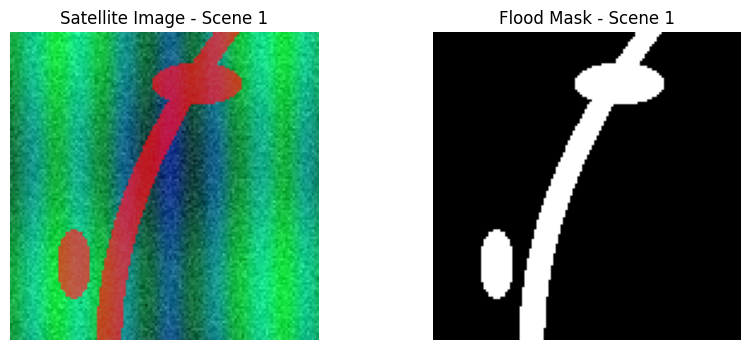

In [4]:
import matplotlib.pyplot as plt

# Pick one scene
idx = 1

image = images[idx]
mask = masks[idx]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Satellite Image - Scene {idx}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title(f"Flood Mask - Scene {idx}")
plt.axis("off")

plt.show()

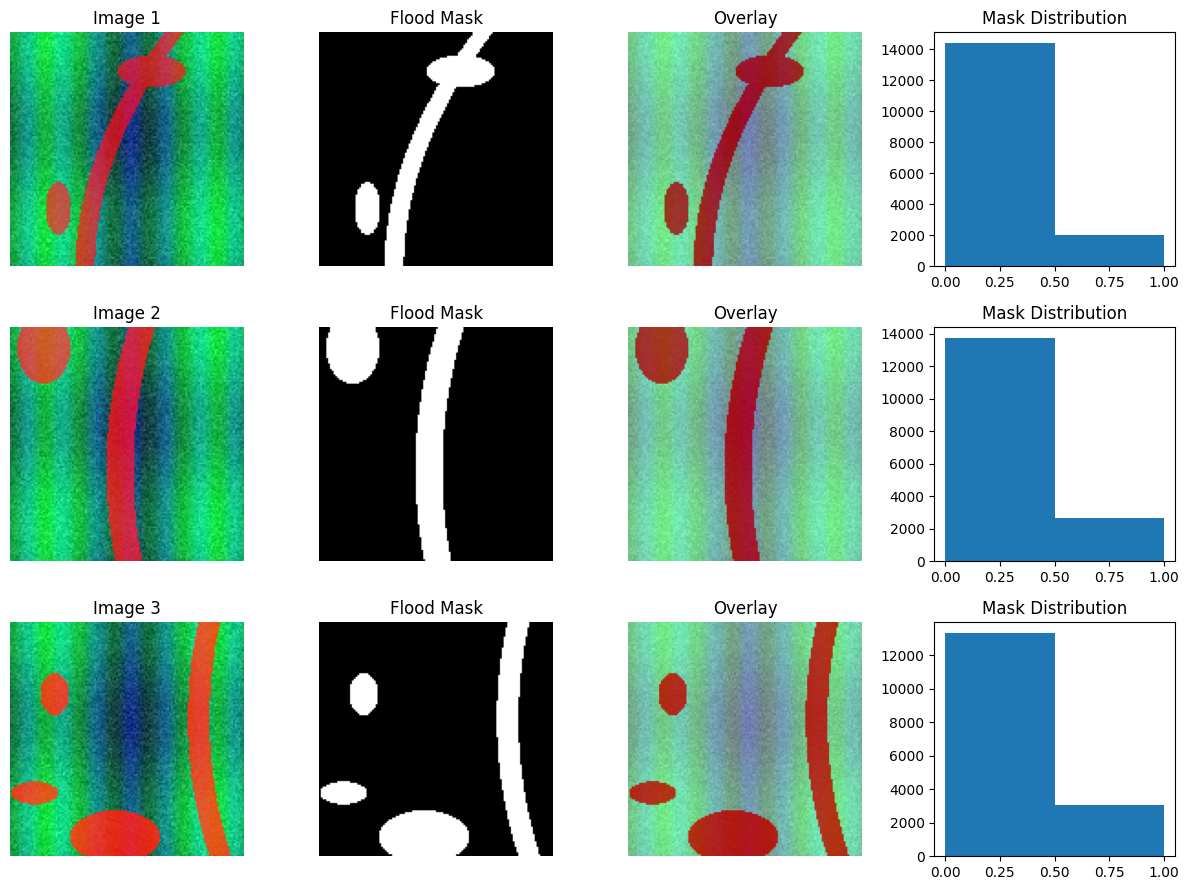

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i in range(3):
    idx = i + 1

    axes[i, 0].imshow(images[idx])
    axes[i, 0].set_title(f"Image {idx}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(masks[idx], cmap="gray")
    axes[i, 1].set_title("Flood Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(images[idx])
    axes[i, 2].imshow(masks[idx], alpha=0.4, cmap="Reds")
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis("off")

    axes[i, 3].hist(masks[idx].flatten(), bins=2)
    axes[i, 3].set_title("Mask Distribution")

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
import numpy as np

# Identify whether each scene contains any flood pixels
has_flood = (masks.sum(axis=(1, 2)) > 0).astype(int)

print("Scenes with flood:", has_flood.sum())
print("Scenes without flood:", (has_flood == 0).sum())

# First split: 70% train, 30% temporary
train_idx, temp_idx = train_test_split(
    np.arange(len(images)),
    test_size=0.30,
    random_state=42,
    stratify=has_flood
)

# Second split: temporary → validation + test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=has_flood[temp_idx]
)

print("\nDataset split:")
print("Training   :", len(train_idx))
print("Validation :", len(val_idx))
print("Testing    :", len(test_idx))

Scenes with flood: 180
Scenes without flood: 20

Dataset split:
Training   : 140
Validation : 30
Testing    : 30


In [7]:
print("\nFlood scenes in each split:")

print(
    "Training:",
    has_flood[train_idx].sum(),
    "/",
    len(train_idx)
)

print(
    "Validation:",
    has_flood[val_idx].sum(),
    "/",
    len(val_idx)
)

print(
    "Testing:",
    has_flood[test_idx].sum(),
    "/",
    len(test_idx)
)


Flood scenes in each split:
Training: 126 / 140
Validation: 27 / 30
Testing: 27 / 30


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader


class FloodSegmentationDataset(Dataset):

    def __init__(self, images, masks, indices):

        self.images = images
        self.masks = masks
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):

        real_idx = self.indices[idx]

        image = self.images[real_idx]
        mask = self.masks[real_idx]

        # Convert image:
        # H, W, C → C, H, W
        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1)

        # Add channel dimension:
        # H, W → 1, H, W
        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

In [9]:
train_dataset = FloodSegmentationDataset(
    images,
    masks,
    train_idx
)

val_dataset = FloodSegmentationDataset(
    images,
    masks,
    val_idx
)

test_dataset = FloodSegmentationDataset(
    images,
    masks,
    test_idx
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 140
Validation samples: 30
Test samples: 30


In [10]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 9
Validation batches: 2
Test batches: 2


In [11]:
images_batch, masks_batch = next(iter(train_loader))

print("Image batch shape:", images_batch.shape)
print("Mask batch shape :", masks_batch.shape)

print("Image range:", images_batch.min().item(), "→", images_batch.max().item())
print("Mask range :", masks_batch.min().item(), "→", masks_batch.max().item())

Image batch shape: torch.Size([16, 3, 128, 128])
Mask batch shape : torch.Size([16, 1, 128, 128])
Image range: 0.0 → 1.0
Mask range : 0.0 → 1.0


In [12]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Bottleneck
        self.bottleneck = DoubleConv(
            512,
            1024
        )

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            1024,
            512
        )

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            512,
            256
        )

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            256,
            128
        )

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            128,
            64
        )

        # Final segmentation layer
        self.output = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        # Bottleneck
        b = self.bottleneck(
            self.pool(e4)
        )

        # Decoder
        d4 = self.up4(b)

        d4 = torch.cat(
            [d4, e4],
            dim=1
        )

        d4 = self.dec4(d4)

        d3 = self.up3(d4)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        return self.output(d1)

In [13]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

unet = UNet().to(device)

print(unet)

Using device: cuda
UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128

In [14]:
images_batch, masks_batch = next(iter(train_loader))

images_batch = images_batch.to(device)

with torch.no_grad():
    output = unet(images_batch)

print("Input shape :", images_batch.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([16, 3, 128, 128])
Output shape: torch.Size([16, 1, 128, 128])


In [15]:
import torch.nn.functional as F


def dice_loss(logits, targets, smooth=1e-6):

    probabilities = torch.sigmoid(logits)

    probabilities = probabilities.view(-1)
    targets = targets.view(-1)

    intersection = (probabilities * targets).sum()

    dice = (
        2 * intersection + smooth
    ) / (
        probabilities.sum()
        + targets.sum()
        + smooth
    )

    return 1 - dice


bce_loss = nn.BCEWithLogitsLoss()


def combined_loss(logits, targets):

    bce = bce_loss(logits, targets)

    dice = dice_loss(
        logits,
        targets
    )

    return bce + dice

In [16]:
def calculate_dice(logits, targets, threshold=0.5):

    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= threshold
    ).float()

    predictions = predictions.view(-1)
    targets = targets.view(-1)

    intersection = (
        predictions * targets
    ).sum()

    dice = (
        2 * intersection + 1e-6
    ) / (
        predictions.sum()
        + targets.sum()
        + 1e-6
    )

    return dice.item()


def calculate_iou(logits, targets, threshold=0.5):

    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= threshold
    ).float()

    predictions = predictions.view(-1)
    targets = targets.view(-1)

    intersection = (
        predictions * targets
    ).sum()

    union = (
        predictions
        + targets
        - predictions * targets
    ).sum()

    iou = (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )

    return iou.item()

In [17]:
optimizer = torch.optim.Adam(
    unet.parameters(),
    lr=1e-4
)

print("Optimizer ready.")

Optimizer ready.


In [18]:
num_epochs = 30

best_val_loss = float("inf")
patience = 7
patience_counter = 0

for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================

    unet.train()

    train_loss = 0.0

    for images_batch, masks_batch in train_loader:

        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        optimizer.zero_grad()

        outputs = unet(images_batch)

        loss = combined_loss(
            outputs,
            masks_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # =========================
    # VALIDATION
    # =========================

    unet.eval()

    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    with torch.no_grad():

        for images_batch, masks_batch in val_loader:

            images_batch = images_batch.to(device)
            masks_batch = masks_batch.to(device)

            outputs = unet(images_batch)

            loss = combined_loss(
                outputs,
                masks_batch
            )

            val_loss += loss.item()

            val_dice += calculate_dice(
                outputs,
                masks_batch
            )

            val_iou += calculate_iou(
                outputs,
                masks_batch
            )

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f}"
    )

    # =========================
    # EARLY STOPPING
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            unet.state_dict(),
            "../models/unet_best.pth"
        )

    else:

        patience_counter += 1

        if patience_counter >= patience:

            print("\nEarly stopping triggered.")
            break

print("\nTraining completed.")
print("Best validation loss:", best_val_loss)

Epoch [01/30] Train Loss: 1.2725 | Val Loss: 1.4652 | Dice: 0.3198 | IoU: 0.1903
Epoch [02/30] Train Loss: 1.0241 | Val Loss: 1.2871 | Dice: 0.9690 | IoU: 0.9398
Epoch [03/30] Train Loss: 0.9390 | Val Loss: 1.0050 | Dice: 0.9427 | IoU: 0.8916
Epoch [04/30] Train Loss: 0.8940 | Val Loss: 0.8682 | Dice: 0.9384 | IoU: 0.8839
Epoch [05/30] Train Loss: 0.8678 | Val Loss: 0.8204 | Dice: 0.9533 | IoU: 0.9108
Epoch [06/30] Train Loss: 0.8474 | Val Loss: 0.7920 | Dice: 0.9652 | IoU: 0.9327
Epoch [07/30] Train Loss: 0.8312 | Val Loss: 0.7696 | Dice: 0.9737 | IoU: 0.9487
Epoch [08/30] Train Loss: 0.8118 | Val Loss: 0.7492 | Dice: 0.9779 | IoU: 0.9568
Epoch [09/30] Train Loss: 0.7947 | Val Loss: 0.7341 | Dice: 0.9787 | IoU: 0.9582
Epoch [10/30] Train Loss: 0.7788 | Val Loss: 0.7222 | Dice: 0.9819 | IoU: 0.9644
Epoch [11/30] Train Loss: 0.7679 | Val Loss: 0.7167 | Dice: 0.9861 | IoU: 0.9726
Epoch [12/30] Train Loss: 0.7569 | Val Loss: 0.7079 | Dice: 0.9875 | IoU: 0.9754
Epoch [13/30] Train Loss: 0.

In [19]:
unet.load_state_dict(
    torch.load(
        "../models/unet_best.pth",
        map_location=device
    )
)

unet.eval()

print("Best U-Net model loaded.")

Best U-Net model loaded.


C:\Users\ADRISH\AppData\Local\Temp\ipykernel_30088\1967789675.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


In [20]:
test_loss = 0.0
test_dice = 0.0
test_iou = 0.0

with torch.no_grad():

    for images_batch, masks_batch in test_loader:

        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        outputs = unet(images_batch)

        loss = combined_loss(
            outputs,
            masks_batch
        )

        test_loss += loss.item()

        test_dice += calculate_dice(
            outputs,
            masks_batch
        )

        test_iou += calculate_iou(
            outputs,
            masks_batch
        )

test_loss /= len(test_loader)
test_dice /= len(test_loader)
test_iou /= len(test_loader)

print("===== U-NET TEST RESULTS =====")

print("Test Loss :", test_loss)
print("Test Dice :", test_dice)
print("Test IoU  :", test_iou)

===== U-NET TEST RESULTS =====
Test Loss : 0.5845019519329071
Test Dice : 0.9997859299182892
Test IoU  : 0.9995719194412231


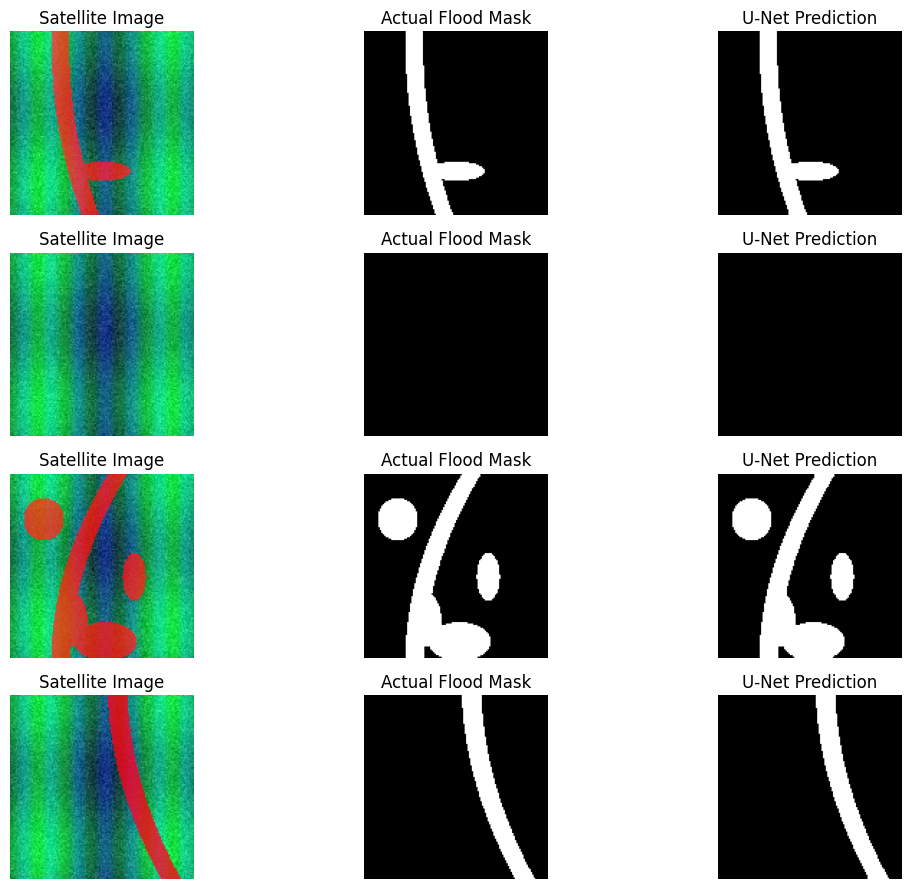

In [23]:
images_batch, masks_batch = next(iter(test_loader))

images_gpu = images_batch.to(device)

with torch.no_grad():

    predictions = unet(images_gpu)

    probabilities = torch.sigmoid(
        predictions
    )

    predicted_masks = (
        probabilities >= 0.5
    ).float()

# Move back to CPU
predicted_masks = predicted_masks.cpu()

plt.figure(figsize=(12, 9))

for i in range(4):

    # Original image
    plt.subplot(4, 3, i * 3 + 1)

    plt.imshow(
        images_batch[i].permute(1, 2, 0)
    )

    plt.title("Satellite Image")
    plt.axis("off")

    # Ground truth
    plt.subplot(4, 3, i * 3 + 2)

    plt.imshow(
        masks_batch[i].squeeze(),
        cmap="gray"
    )

    plt.title("Actual Flood Mask")
    plt.axis("off")

    # Prediction
    plt.subplot(4, 3, i * 3 + 3)

    plt.imshow(
        predicted_masks[i].squeeze(),
        cmap="gray"
    )

    plt.title("U-Net Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
flood_pixels = predicted_masks[i].sum().item()

total_pixels = predicted_masks[i].numel()

flood_fraction = (
    flood_pixels / total_pixels
)

print(
    f"Flooded Area: {flood_fraction * 100:.2f}%"
)

Flooded Area: 10.73%


In [21]:
def calculate_flood_fraction(predicted_mask):
    
    flood_pixels = predicted_mask.sum().item()
    
    total_pixels = predicted_mask.numel()
    
    return flood_pixels / total_pixels

In [25]:
for i in range(5):

    fraction = calculate_flood_fraction(
        predicted_masks[i]
    )

    print(
        f"Scene {i}: "
        f"{fraction * 100:.2f}% flooded"
    )

Scene 0: 11.71% flooded
Scene 1: 0.00% flooded
Scene 2: 23.78% flooded
Scene 3: 10.73% flooded
Scene 4: 16.84% flooded


In [28]:
metadata = pd.read_csv(
    "../data/raw/satellite_segmentation/metadata.csv"
)

print(metadata.head())
print("\nMetadata shape:", metadata.shape)

     image_id  flood_pixels  flood_fraction
0  scene_0000             0        0.000000
1  scene_0001          2008        0.122559
2  scene_0002          2661        0.162415
3  scene_0003          3087        0.188416
4  scene_0004          2371        0.144714

Metadata shape: (200, 3)


In [30]:
# Calculate predicted flood fraction
predicted_fractions = []

for i in range(len(predicted_masks)):

    fraction = (
        predicted_masks[i].sum().item()
        / predicted_masks[i].numel()
    )

    predicted_fractions.append(fraction)


# Scene IDs corresponding to this test batch
test_scene_indices = test_idx[:len(predicted_fractions)]

comparison = pd.DataFrame({
    "image_id": [
        f"scene_{idx:04d}"
        for idx in test_scene_indices
    ],
    "predicted_flood_fraction": predicted_fractions
})


# Merge with ground truth metadata
comparison = comparison.merge(
    metadata[
        ["image_id", "flood_fraction"]
    ],
    on="image_id",
    how="left"
)


# Convert to percentages
comparison["predicted_flood_percent"] = (
    comparison["predicted_flood_fraction"] * 100
)

comparison["actual_flood_percent"] = (
    comparison["flood_fraction"] * 100
)


# Absolute error
comparison["absolute_error_percent"] = (
    comparison["predicted_flood_percent"]
    - comparison["actual_flood_percent"]
).abs()


comparison.head(10)

,image_id,predicted_flood_fraction,flood_fraction,predicted_flood_percent,actual_flood_percent,absolute_error_percent
0,scene_0093,0.117126,0.117065,11.712646,11.706543,0.006104
1,scene_0040,0.000000,0.000000,0.000000,0.000000,0.000000
2,scene_0191,0.237793,0.237549,23.779297,23.754883,0.024414
3,scene_0105,0.107300,0.107239,10.729980,10.723877,0.006104
4,scene_0081,0.168396,0.168274,16.839600,16.827393,0.012207
5,scene_0119,0.115967,0.115967,11.596680,11.596680,0.000000
6,scene_0099,0.231567,0.231567,23.156738,23.156738,0.000000
7,scene_0115,0.136292,0.136230,13.629150,13.623047,0.006104
8,scene_0171,0.174133,0.174072,17.413330,17.407227,0.006104
9,scene_0060,0.000000,0.000000,0.000000,0.000000,0.000000


In [31]:
mae = comparison["absolute_error_percent"].mean()

print("===== FLOODED AREA ESTIMATION =====")
print(f"Mean Absolute Error: {mae:.4f}%")

===== FLOODED AREA ESTIMATION =====
Mean Absolute Error: 0.0046%


In [32]:
print(
    comparison[
        [
            "actual_flood_percent",
            "predicted_flood_percent"
        ]
    ].describe()
)

       actual_flood_percent  predicted_flood_percent
count             16.000000                16.000000
mean              13.409805                13.414383
std                6.964198                 6.966993
min                0.000000                 0.000000
25%               10.635376                10.639954
50%               13.455200                13.464355
75%               17.742920                17.747498
max               23.754883                23.779297
